Synthetic Energy Dataset Generated Successfully!
                       energy_MW
Datetime                        
2020-01-01 00:00:00  2108.897784
2020-01-01 01:00:00  2403.497330
2020-01-01 02:00:00  2117.765285
2020-01-01 03:00:00  2456.603960
2020-01-01 04:00:00  2459.145129


C:\Users\thali\AppData\Local\Temp\ipykernel_3284\2495986434.py:6: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  dates = pd.date_range(start='2020-01-01', end='2024-01-01', freq='H')


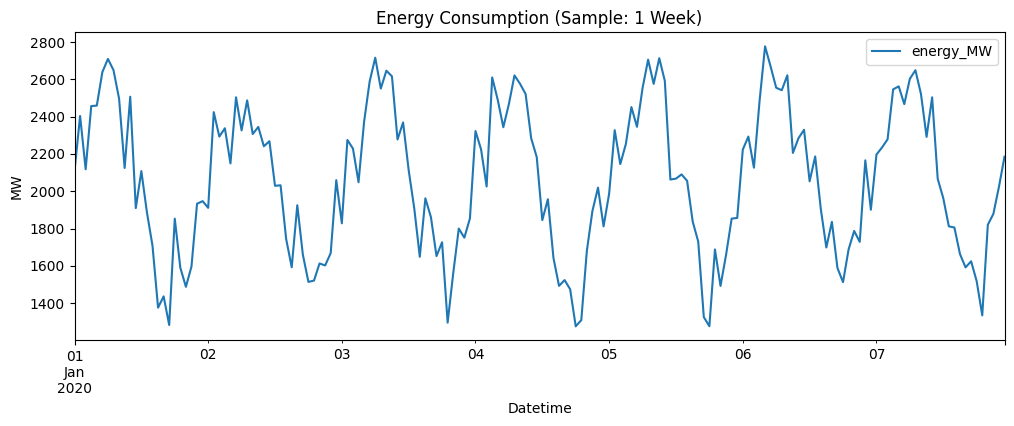

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Create a datetime range for 4 years with hourly frequency
dates = pd.date_range(start='2020-01-01', end='2024-01-01', freq='H')
n = len(dates)

# 2. Simulate realistic energy patterns
# Base load + Daily cycle + Yearly seasonality + Random noise
base = 2000 
daily_cycle = 500 * np.sin(2 * np.pi * dates.hour / 24)
yearly_cycle = 1000 * np.sin(2 * np.pi * dates.dayofyear / 365)
noise = np.random.normal(0, 150, n)

energy_values = base + daily_cycle + yearly_cycle + noise

# 3. Create the main DataFrame
df = pd.DataFrame({'energy_MW': energy_values}, index=dates)
df.index.name = 'Datetime'

print("Synthetic Energy Dataset Generated Successfully!")
print(df.head())

# A weeks visuals to check the cirle
df.iloc[:24*7].plot(figsize=(12, 4), title='Energy Consumption (Sample: 1 Week)')
plt.ylabel('MW')
plt.show()
    

In [15]:
def create_time_features(df):
    """
    Creates time series features based on datetime index.
    """
    df = df.copy()
    df['hour'] = df.index.hour
    df['dayofweek'] = df.index.dayofweek
    df['quarter'] = df.index.quarter
    df['month'] = df.index.month
    df['year'] = df.index.year
    
    # Lag Features: Use past values to predict the future
    # lag_24h represents the energy consumption exactly 1 day ago
    df['lag_24h'] = df['energy_MW'].shift(24)
    # lag_7d represents the energy consumption exactly 1 week ago
    df['lag_7d'] = df['energy_MW'].shift(24*7)
    
    # Remove rows with NaN values caused by shifting
    return df.dropna()

# Apply the feature engineering function
df_features = create_time_features(df)

In [16]:
# Train/test (Time-based split)
import xgboost as xgb

train = df_features.loc[df_features.index < '2023-01-01']
test = df_features.loc[df_features.index >= '2023-01-01']

# 2. Χρήση του σωστού ονόματος στήλης 'energy_MW'
X_train = train.drop('energy_MW', axis=1)
y_train = train['energy_MW']

X_test = test.drop('energy_MW', axis=1)
y_test = test['energy_MW']

# 3. Εκπαίδευση του μοντέλου
model = xgb.XGBRegressor(n_estimators=1000, learning_rate=0.01)
model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=100)

[0]	validation_0-rmse:797.41902
[100]	validation_0-rmse:338.92423
[200]	validation_0-rmse:205.56935
[300]	validation_0-rmse:177.13218
[400]	validation_0-rmse:171.08941
[500]	validation_0-rmse:169.61834
[600]	validation_0-rmse:169.08372
[700]	validation_0-rmse:168.85804
[800]	validation_0-rmse:168.70195
[900]	validation_0-rmse:168.63012
[999]	validation_0-rmse:168.59535


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

C:\Users\thali\AppData\Local\Temp\ipykernel_3284\1630036466.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['prediction'] = model.predict(X_test)


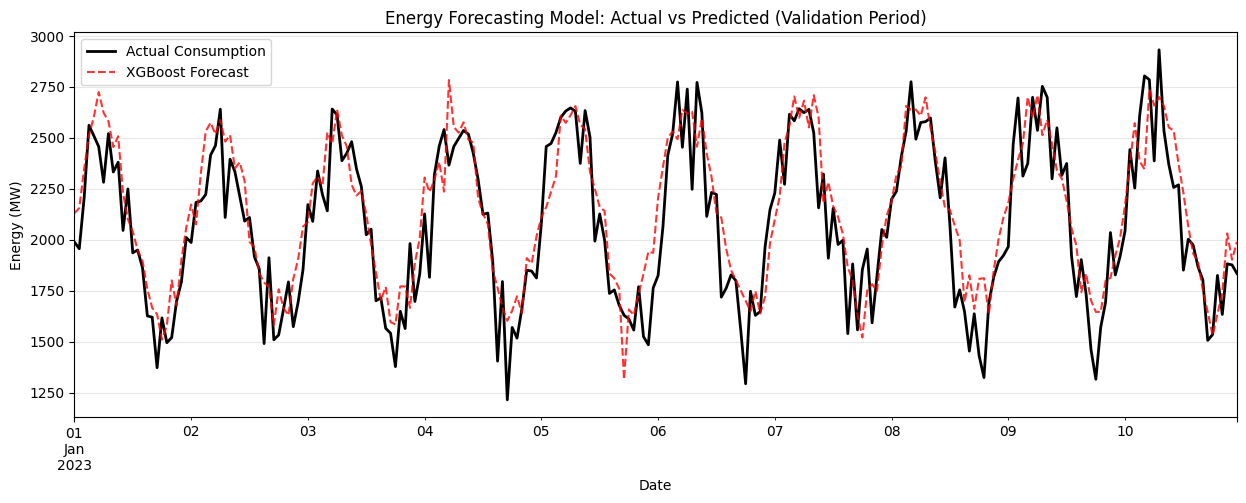

R2 Score: 0.9561 (95.61% of variance explained)


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score 

# 1. Generate predictions on the test set
test['prediction'] = model.predict(X_test)

# 2. Plot the results for a 10-day window
plt.figure(figsize=(15, 5))
test['energy_MW'].iloc[:240].plot(label='Actual Consumption', color='black', linewidth=2)
test['prediction'].iloc[:240].plot(label='XGBoost Forecast', color='red', linestyle='--', alpha=0.8)

plt.title('Energy Forecasting Model: Actual vs Predicted (Validation Period)')
plt.xlabel('Date')
plt.ylabel('Energy (MW)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 3. Calculate Accuracy Metric
r2 = r2_score(test['energy_MW'], test['prediction'])
print(f"R2 Score: {r2:.4f} ({r2*100:.2f}% of variance explained)")